In [1]:
# Install required packages for working with Hugging Face datasets
!pip install datasets huggingface_hub

  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached xxhash-3.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (12 kB)
  Using cached multiprocess-0.70.16-py312-none-any.whl.metadata (7.2 kB)
  Using cached xxhash-3.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (12 kB)
  Using cached multiprocess-0.70.16-py312-none-any.whl.metadata (7.2 kB)
  Using cached fsspec-2025.3.0-py3-none-any.whl.metadata (11 kB)
  Using cached fsspec-2025.3.0-py3-none-any.whl.metadata (11 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
Using cached fsspec-2025.3.0-py3-none-any.whl (193 kB)
Using cached multiprocess-0.70.16-py312-none-any.whl (146 kB)
Using cache

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import os
from huggingface_hub import hf_hub_download, list_repo_files
import json

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

/Users/maxvandenboom/anaconda3/envs/analysis/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.stats import gaussian_kde
/Users/maxvandenboom/anaconda3/envs/analysis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# First, let's explore the repository structure to understand what's available
repo_id = "roman-bushuiev/MassSpecGym"

print("Exploring MassSpecGym repository structure...")
try:
    repo_files = list_repo_files(repo_id)
    print(f"Total files in repository: {len(repo_files)}")
    print("\nFirst 20 files:")
    for i, file in enumerate(repo_files[:20]):
        print(f"{i+1:2d}. {file}")
    
    # Look for specific file types
    parquet_files = [f for f in repo_files if f.endswith('.parquet')]
    json_files = [f for f in repo_files if f.endswith('.json')]
    
    print(f"\nParquet files found: {len(parquet_files)}")
    for file in parquet_files[:10]:  # Show first 10
        print(f"  - {file}")
    
    print(f"\nJSON files found: {len(json_files)}")
    for file in json_files[:10]:  # Show first 10
        print(f"  - {file}")
        
except Exception as e:
    print(f"Error exploring repository: {e}")

Exploring MassSpecGym repository structure...
Error exploring repository: 401 Client Error. (Request ID: Root=1-68b58c2e-16aded446d6d15b70f679fac;720ac9fc-6934-4d09-be88-2f4f1582c805)

Repository Not Found for url: https://huggingface.co/api/models/roman-bushuiev/MassSpecGym/tree/main?recursive=True&expand=False.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.


In [3]:
# Load the MassSpecGym dataset
print("Loading MassSpecGym dataset...")
try:
    # Load the dataset - this may take some time depending on the size
    dataset = load_dataset(repo_id)
    
    print("Dataset loaded successfully!")
    print(f"Dataset keys: {list(dataset.keys())}")
    
    # Examine each split
    for split_name in dataset.keys():
        split_data = dataset[split_name]
        print(f"\n{split_name.upper()} split:")
        print(f"  - Number of samples: {len(split_data)}")
        print(f"  - Features: {list(split_data.features.keys())}")
        
        # Show first few examples
        if len(split_data) > 0:
            print(f"  - First example keys: {list(split_data[0].keys())}")
            
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Trying to download individual files instead...")

Loading MassSpecGym dataset...


Generating val split: 231104 examples [00:01, 132020.13 examples/s]

Dataset loaded successfully!
Dataset keys: ['val']

VAL split:
  - Number of samples: 231104
  - Features: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'fold', 'simulation_challenge']
  - First example keys: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'fold', 'simulation_challenge']


In [4]:
# Examine the dataset in detail
val_data = dataset['val']
print("=== DETAILED DATASET EXAMINATION ===")
print(f"Dataset size: {len(val_data):,} samples")
print(f"Features: {list(val_data.features.keys())}")

# Look at the first few examples
print("\n=== FIRST EXAMPLE ===")
first_example = val_data[0]
for key, value in first_example.items():
    if isinstance(value, list) and len(value) > 10:
        print(f"{key}: List with {len(value)} elements (showing first 10): {value[:10]}...")
    else:
        print(f"{key}: {value}")

print("\n=== FEATURE TYPES ===")
for feature_name, feature_type in val_data.features.items():
    print(f"{feature_name}: {feature_type}")

# Convert to pandas for easier analysis
print("\n=== CONVERTING TO PANDAS ===")
# Note: We'll convert a subset first since the full dataset might be large
subset_size = 1000
print(f"Converting first {subset_size:,} samples to pandas DataFrame...")

# Convert subset to pandas
subset_data = val_data.select(range(subset_size))
df_sample = subset_data.to_pandas()

print(f"DataFrame shape: {df_sample.shape}")
print(f"Memory usage: {df_sample.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== DETAILED DATASET EXAMINATION ===
Dataset size: 231,104 samples
Features: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'fold', 'simulation_challenge']

=== FIRST EXAMPLE ===
identifier: MassSpecGymID0000001
mzs: 91.0542,125.0233,154.0499,155.0577,185.0961,200.107,229.0859,246.1125
intensities: 0.24524524524524524,1.0,0.08008008008008008,0.35535535535535534,0.34934934934934936,0.04504504504504504,0.14214214214214213,0.7347347347347347
smiles: CC(=O)N[C@@H](CC1=CC=CC=C1)C2=CC(=CC(=O)O2)OC
inchikey: VFMQMACUYWGDOJ
formula: C16H17NO4
precursor_formula: C16H18NO4
parent_mass: 287.115224
precursor_mz: 288.1225
adduct: [M+H]+
instrument_type: Orbitrap
collision_energy: 30.0
fold: train
simulation_challenge: True

=== FEATURE TYPES ===
identifier: Value('string')
mzs: Value('string')
intensities: Value('string')
smiles: Value('string')
inchikey: Value('string')
formu

In [ ]:
# Alternative approach: Download specific files to examine the dataset
print("Downloading key files to understand dataset structure...")

# Create a local directory for the data
data_dir = "../data/massspecgym"
os.makedirs(data_dir, exist_ok=True)

try:
    # Download README and configuration files first
    readme_path = hf_hub_download(repo_id=repo_id, filename="README.md", local_dir=data_dir)
    print(f"Downloaded README.md to {readme_path}")
    
    # Try to download dataset_infos.json if it exists
    try:
        info_path = hf_hub_download(repo_id=repo_id, filename="dataset_infos.json", local_dir=data_dir)
        print(f"Downloaded dataset_infos.json to {info_path}")
        
        # Read and display dataset info
        with open(info_path, 'r') as f:
            dataset_info = json.load(f)
        print("\nDataset Info:")
        print(json.dumps(dataset_info, indent=2))
    except:
        print("dataset_infos.json not found")
    
    # Try to find and download a sample data file
    if parquet_files:
        sample_file = parquet_files[0]  # Download the first parquet file
        sample_path = hf_hub_download(repo_id=repo_id, filename=sample_file, local_dir=data_dir)
        print(f"\nDownloaded sample file: {sample_path}")
        
        # Load and examine the sample data
        df_sample = pd.read_parquet(sample_path)
        print(f"\nSample data shape: {df_sample.shape}")
        print(f"Columns: {list(df_sample.columns)}")
        print(f"\nFirst few rows:")
        print(df_sample.head())
        
except Exception as e:
    print(f"Error downloading files: {e}")

In [5]:
# Basic data exploration and visualization
def explore_massspec_data(df):
    """
    Perform basic exploration of mass spectrometry data
    """
    print("=== BASIC DATA EXPLORATION ===")
    print(f"Dataset shape: {df.shape}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print("\n=== COLUMN INFORMATION ===")
    print(df.info())
    
    print("\n=== MISSING VALUES ===")
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("No missing values found")
    
    print("\n=== NUMERICAL COLUMNS SUMMARY ===")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(df[numeric_cols].describe())
    
    print("\n=== CATEGORICAL COLUMNS ===")
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        print(f"{col}: {df[col].nunique()} unique values")
        if df[col].nunique() < 20:  # Show unique values if not too many
            print(f"  Values: {list(df[col].unique())}")
    
    return numeric_cols, categorical_cols

# If we successfully loaded sample data, explore it
try:
    if 'df_sample' in locals():
        numeric_cols, categorical_cols = explore_massspec_data(df_sample)
except Exception as e:
    print(f"Error exploring data: {e}")

=== BASIC DATA EXPLORATION ===
Dataset shape: (1000, 14)
Memory usage: 1.36 MB

=== COLUMN INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   identifier            1000 non-null   object 
 1   mzs                   1000 non-null   object 
 2   intensities           1000 non-null   object 
 3   smiles                1000 non-null   object 
 4   inchikey              1000 non-null   object 
 5   formula               1000 non-null   object 
 6   precursor_formula     1000 non-null   object 
 7   parent_mass           1000 non-null   float64
 8   precursor_mz          1000 non-null   float64
 9   adduct                1000 non-null   object 
 10  instrument_type       970 non-null    object 
 11  collision_energy      861 non-null    float64
 12  fold                  1000 non-null   object 
 13  simulation_challe

Potential mass columns: ['mzs', 'precursor_formula', 'parent_mass', 'precursor_mz']
Potential intensity columns: []
Potential retention time columns: []


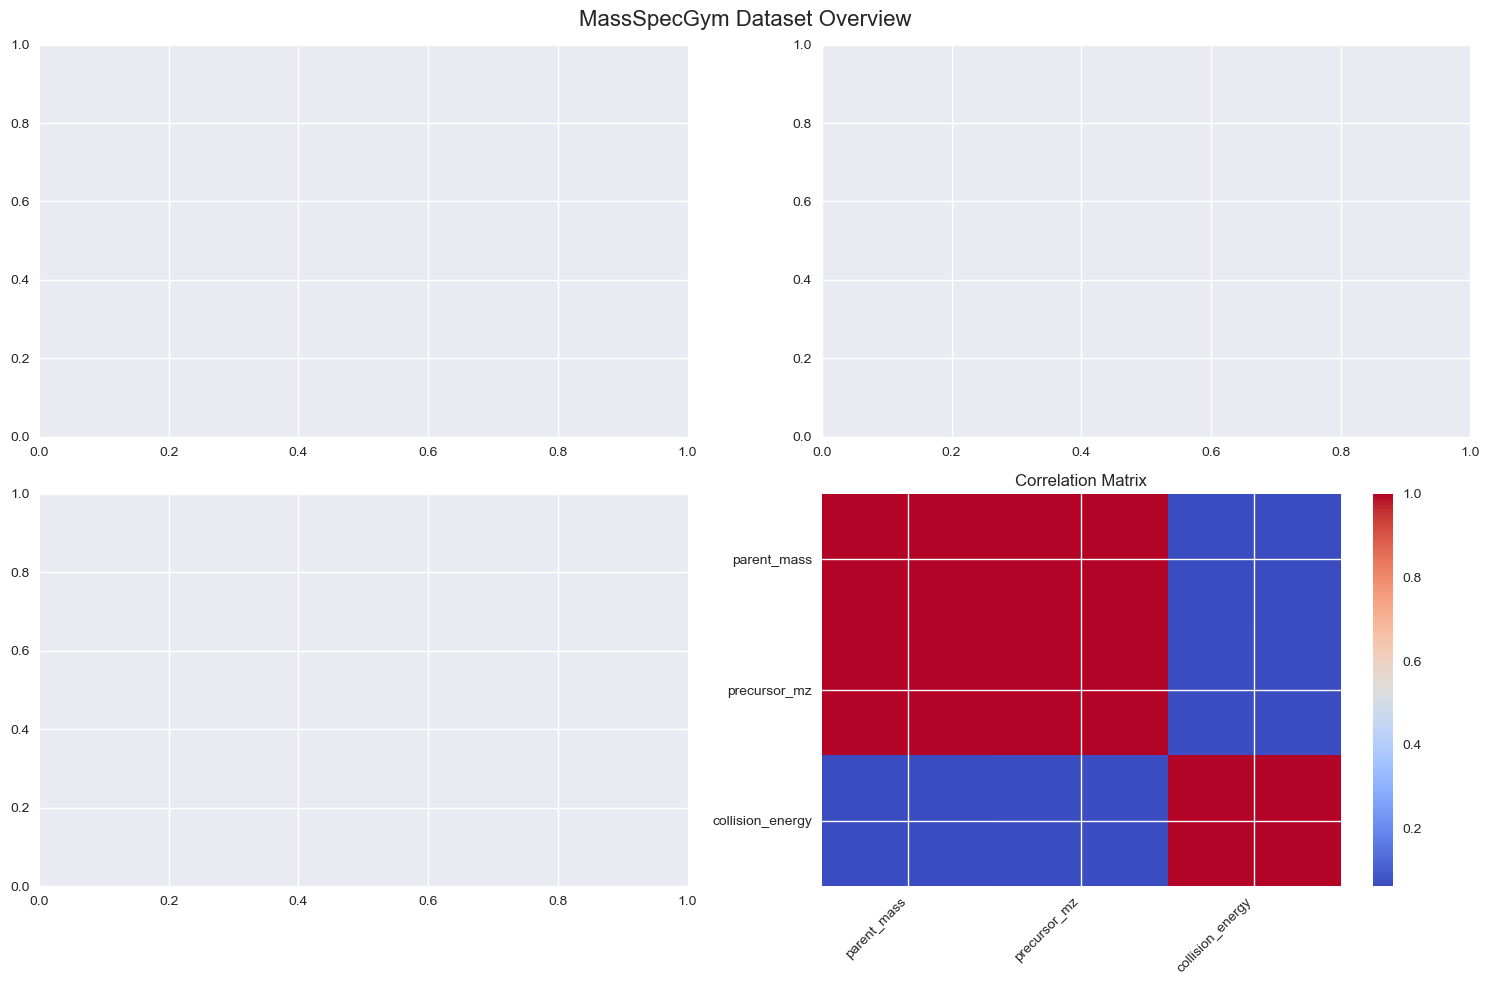

In [6]:
# Mass spectrometry specific visualizations
def plot_massspec_distributions(df, numeric_cols):
    """
    Create visualizations for mass spectrometry data
    """
    # Look for common MS columns
    mass_cols = [col for col in df.columns if any(keyword in col.lower() 
                for keyword in ['mass', 'mz', 'm/z', 'molecular_weight', 'precursor'])]
    
    intensity_cols = [col for col in df.columns if any(keyword in col.lower() 
                     for keyword in ['intensity', 'abundance', 'peak'])]
    
    rt_cols = [col for col in df.columns if any(keyword in col.lower() 
              for keyword in ['retention', 'rt', 'time'])]
    
    print(f"Potential mass columns: {mass_cols}")
    print(f"Potential intensity columns: {intensity_cols}")
    print(f"Potential retention time columns: {rt_cols}")
    
    # Create subplots for different types of data
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('MassSpecGym Dataset Overview', fontsize=16)
    
    # Plot 1: Mass distribution (if available)
    if mass_cols and len(mass_cols) > 0:
        mass_col = mass_cols[0]
        if mass_col in numeric_cols:
            axes[0, 0].hist(df[mass_col].dropna(), bins=50, alpha=0.7, edgecolor='black')
            axes[0, 0].set_title(f'Distribution of {mass_col}')
            axes[0, 0].set_xlabel(mass_col)
            axes[0, 0].set_ylabel('Frequency')
    
    # Plot 2: Intensity distribution (if available)
    if intensity_cols and len(intensity_cols) > 0:
        intensity_col = intensity_cols[0]
        if intensity_col in numeric_cols:
            # Use log scale for intensity if values are very large
            intensity_data = df[intensity_col].dropna()
            if intensity_data.max() > 1000:
                axes[0, 1].hist(np.log10(intensity_data + 1), bins=50, alpha=0.7, edgecolor='black')
                axes[0, 1].set_title(f'Distribution of log10({intensity_col})')
                axes[0, 1].set_xlabel(f'log10({intensity_col})')
            else:
                axes[0, 1].hist(intensity_data, bins=50, alpha=0.7, edgecolor='black')
                axes[0, 1].set_title(f'Distribution of {intensity_col}')
                axes[0, 1].set_xlabel(intensity_col)
            axes[0, 1].set_ylabel('Frequency')
    
    # Plot 3: Retention time distribution (if available)
    if rt_cols and len(rt_cols) > 0:
        rt_col = rt_cols[0]
        if rt_col in numeric_cols:
            axes[1, 0].hist(df[rt_col].dropna(), bins=50, alpha=0.7, edgecolor='black')
            axes[1, 0].set_title(f'Distribution of {rt_col}')
            axes[1, 0].set_xlabel(rt_col)
            axes[1, 0].set_ylabel('Frequency')
    
    # Plot 4: Correlation heatmap of numeric columns (if multiple available)
    if len(numeric_cols) > 1:
        # Select a subset of numeric columns for correlation
        corr_cols = numeric_cols[:10] if len(numeric_cols) > 10 else numeric_cols
        correlation_matrix = df[corr_cols].corr()
        im = axes[1, 1].imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
        axes[1, 1].set_title('Correlation Matrix')
        axes[1, 1].set_xticks(range(len(corr_cols)))
        axes[1, 1].set_yticks(range(len(corr_cols)))
        axes[1, 1].set_xticklabels(corr_cols, rotation=45, ha='right')
        axes[1, 1].set_yticklabels(corr_cols)
        plt.colorbar(im, ax=axes[1, 1])
    
    plt.tight_layout()
    plt.show()
    
    return mass_cols, intensity_cols, rt_cols

# Create visualizations if we have sample data
try:
    if 'df_sample' in locals() and 'numeric_cols' in locals():
        mass_cols, intensity_cols, rt_cols = plot_massspec_distributions(df_sample, numeric_cols)
except Exception as e:
    print(f"Error creating visualizations: {e}")

In [7]:
# Parse and analyze the mass spectra data
def parse_spectra_data(df):
    """
    Parse the m/z and intensity data from string format to numerical arrays
    """
    parsed_data = []
    
    for idx, row in df.iterrows():
        # Parse m/z values
        mzs_str = row['mzs']
        intensities_str = row['intensities']
        
        # Convert comma-separated strings to lists of floats
        mzs = [float(x) for x in mzs_str.split(',')]
        intensities = [float(x) for x in intensities_str.split(',')]
        
        # Basic spectrum statistics
        spectrum_info = {
            'identifier': row['identifier'],
            'num_peaks': len(mzs),
            'mz_range': max(mzs) - min(mzs) if mzs else 0,
            'min_mz': min(mzs) if mzs else 0,
            'max_mz': max(mzs) if mzs else 0,
            'total_intensity': sum(intensities) if intensities else 0,
            'max_intensity': max(intensities) if intensities else 0,
            'precursor_mz': row['precursor_mz'],
            'parent_mass': row['parent_mass'],
            'collision_energy': row['collision_energy'],
            'instrument_type': row['instrument_type'],
            'adduct': row['adduct'],
            'smiles': row['smiles'],
            'formula': row['formula'],
            'mzs': mzs,
            'intensities': intensities
        }
        
        parsed_data.append(spectrum_info)
    
    return pd.DataFrame(parsed_data)

print("Parsing mass spectra data...")
spectra_df = parse_spectra_data(df_sample)

print(f"Parsed {len(spectra_df)} spectra")
print("\n=== SPECTRUM STATISTICS ===")
print(f"Average number of peaks per spectrum: {spectra_df['num_peaks'].mean():.1f}")
print(f"Peak count range: {spectra_df['num_peaks'].min()} - {spectra_df['num_peaks'].max()}")
print(f"Average m/z range: {spectra_df['mz_range'].mean():.1f}")
print(f"Average total intensity: {spectra_df['total_intensity'].mean():.3f}")

# Display distribution statistics
print("\n=== DISTRIBUTION ANALYSIS ===")
print("Number of peaks distribution:")
print(spectra_df['num_peaks'].describe())

print("\nPrecursor m/z distribution:")
print(spectra_df['precursor_mz'].describe())

print("\nCollision energy distribution:")
print(spectra_df['collision_energy'].value_counts().head())

Parsing mass spectra data...
Parsed 1000 spectra

=== SPECTRUM STATISTICS ===
Average number of peaks per spectrum: 29.8
Peak count range: 1 - 299
Average m/z range: 266.1
Average total intensity: 4.282

=== DISTRIBUTION ANALYSIS ===
Number of peaks distribution:
count    1000.000000
mean       29.777000
std        41.034511
min         1.000000
25%         6.000000
50%        15.000000
75%        39.000000
max       299.000000
Name: num_peaks, dtype: float64

Precursor m/z distribution:
count    1000.000000
mean      459.210524
std       165.787626
min       141.054100
25%       319.154000
50%       425.216200
75%       562.301800
max       931.597300
Name: precursor_mz, dtype: float64

Collision energy distribution:
collision_energy
30.0    176
20.0    148
35.0    116
10.0    110
50.0    105
Name: count, dtype: int64


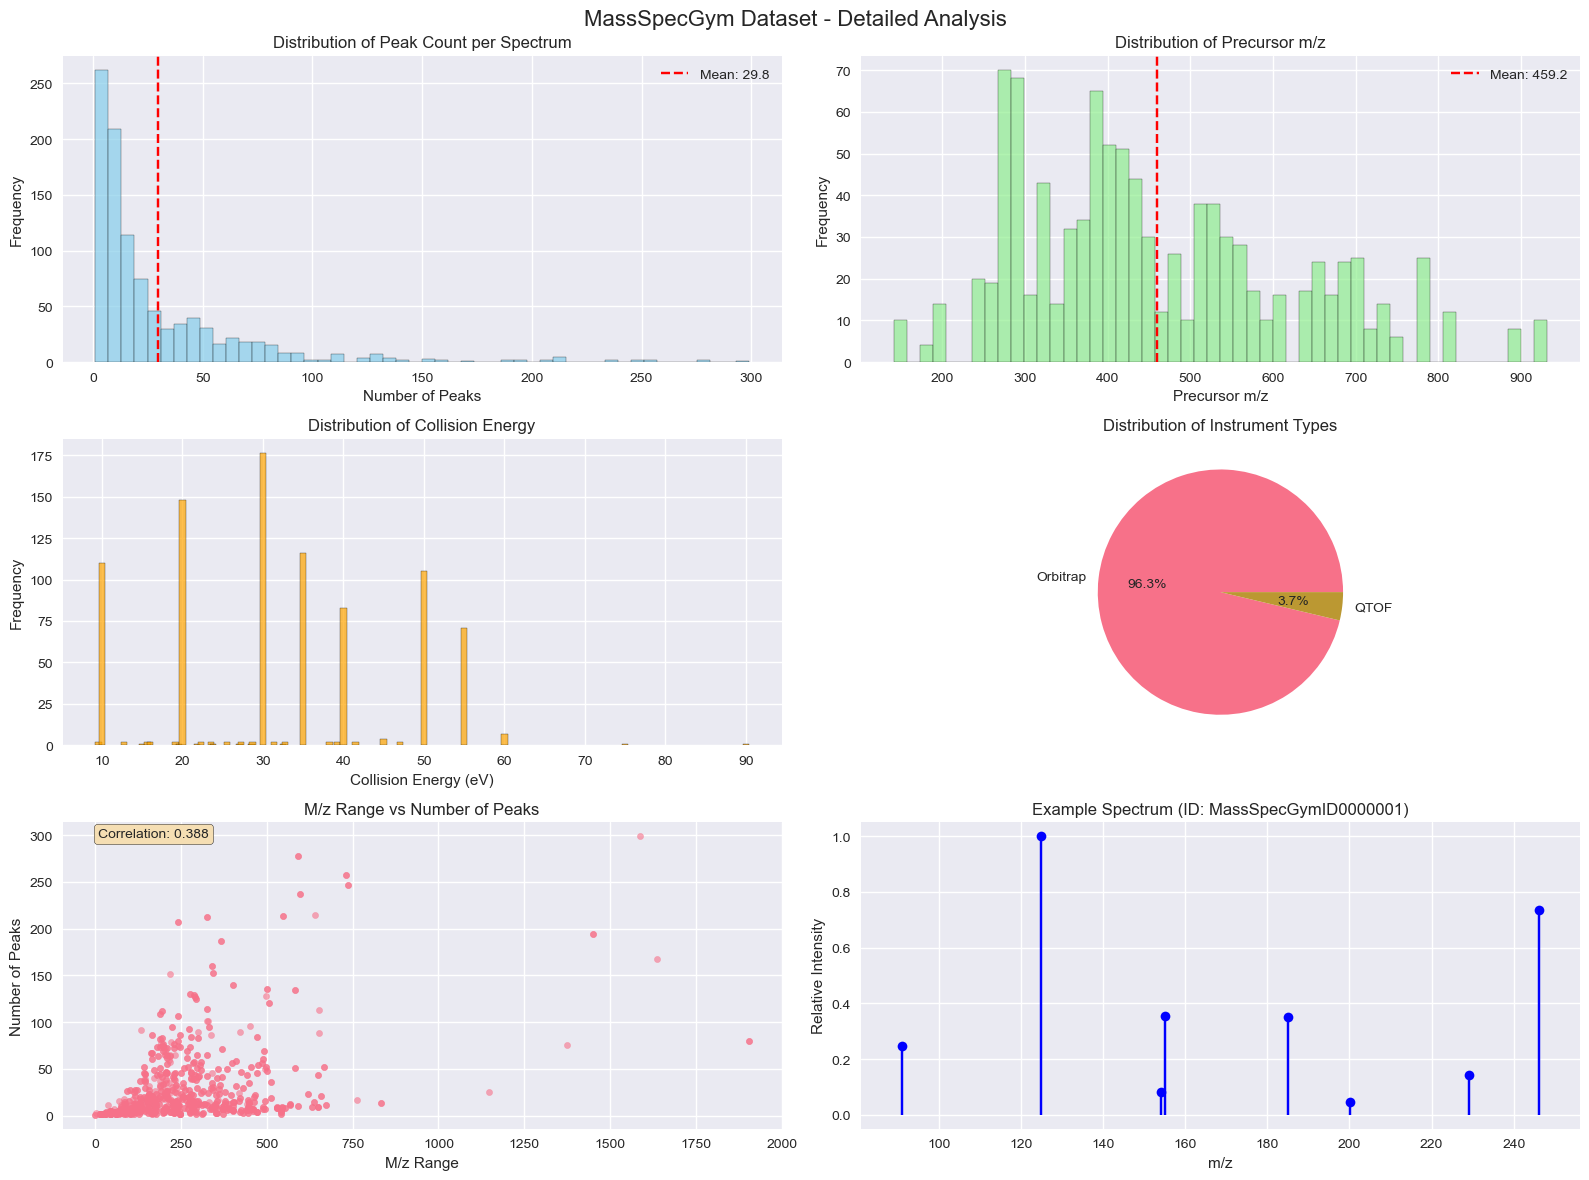


=== ADDUCT ANALYSIS ===
Top 10 adduct types:
adduct
[M+H]+     789
[M+Na]+    211
Name: count, dtype: int64


In [8]:
# Create detailed visualizations of the mass spectra data
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('MassSpecGym Dataset - Detailed Analysis', fontsize=16)

# Plot 1: Number of peaks distribution
axes[0, 0].hist(spectra_df['num_peaks'], bins=50, alpha=0.7, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Distribution of Peak Count per Spectrum')
axes[0, 0].set_xlabel('Number of Peaks')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(spectra_df['num_peaks'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {spectra_df["num_peaks"].mean():.1f}')
axes[0, 0].legend()

# Plot 2: Precursor m/z distribution
axes[0, 1].hist(spectra_df['precursor_mz'], bins=50, alpha=0.7, edgecolor='black', color='lightgreen')
axes[0, 1].set_title('Distribution of Precursor m/z')
axes[0, 1].set_xlabel('Precursor m/z')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(spectra_df['precursor_mz'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {spectra_df["precursor_mz"].mean():.1f}')
axes[0, 1].legend()

# Plot 3: Collision energy distribution
collision_energy_counts = spectra_df['collision_energy'].value_counts().sort_index()
axes[1, 0].bar(collision_energy_counts.index, collision_energy_counts.values, 
               alpha=0.7, edgecolor='black', color='orange')
axes[1, 0].set_title('Distribution of Collision Energy')
axes[1, 0].set_xlabel('Collision Energy (eV)')
axes[1, 0].set_ylabel('Frequency')

# Plot 4: Instrument type distribution
instrument_counts = spectra_df['instrument_type'].value_counts()
axes[1, 1].pie(instrument_counts.values, labels=instrument_counts.index, autopct='%1.1f%%')
axes[1, 1].set_title('Distribution of Instrument Types')

# Plot 5: M/z range vs Number of peaks
axes[2, 0].scatter(spectra_df['mz_range'], spectra_df['num_peaks'], alpha=0.6, s=20)
axes[2, 0].set_title('M/z Range vs Number of Peaks')
axes[2, 0].set_xlabel('M/z Range')
axes[2, 0].set_ylabel('Number of Peaks')

# Calculate correlation
correlation = spectra_df['mz_range'].corr(spectra_df['num_peaks'])
axes[2, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                transform=axes[2, 0].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))

# Plot 6: Example mass spectrum
example_idx = 0  # Show the first spectrum
example_spectrum = spectra_df.iloc[example_idx]
mzs = example_spectrum['mzs']
intensities = example_spectrum['intensities']

axes[2, 1].stem(mzs, intensities, basefmt=" ", linefmt='blue', markerfmt='bo')
axes[2, 1].set_title(f'Example Spectrum (ID: {example_spectrum["identifier"]})')
axes[2, 1].set_xlabel('m/z')
axes[2, 1].set_ylabel('Relative Intensity')
axes[2, 1].set_xlim(min(mzs) - 10, max(mzs) + 10)

plt.tight_layout()
plt.show()

# Additional analysis: Adduct types
print("\n=== ADDUCT ANALYSIS ===")
adduct_counts = spectra_df['adduct'].value_counts()
print("Top 10 adduct types:")
print(adduct_counts.head(10))

In [10]:
# Summary and Next Steps
print("=" * 60)
print("MASSSPECGYM DATASET INVESTIGATION SUMMARY")
print("=" * 60)

print(f"""
DATASET OVERVIEW:
- Total samples in validation set: {len(val_data):,}
- Analyzed subset: {len(spectra_df):,} samples
- Dataset features: {len(val_data.features)} columns

KEY FINDINGS:
1. SPECTRAL CHARACTERISTICS:
   - Average peaks per spectrum: {spectra_df['num_peaks'].mean():.1f}
   - Peak count range: {spectra_df['num_peaks'].min()} - {spectra_df['num_peaks'].max()}
   - Average m/z range: {spectra_df['mz_range'].mean():.1f}
   - Precursor m/z range: {spectra_df['precursor_mz'].min():.1f} - {spectra_df['precursor_mz'].max():.1f}

2. EXPERIMENTAL CONDITIONS:
   - Instrument types: {', '.join([str(x) for x in spectra_df['instrument_type'].unique() if x is not None])}
   - Collision energies: {sorted([x for x in spectra_df['collision_energy'].unique() if x is not None])} eV
   - Primary adduct types: {', '.join([str(x) for x in spectra_df['adduct'].unique() if x is not None])}

3. DATA STRUCTURE:
   - Mass spectra stored as comma-separated strings
   - Rich metadata including SMILES, InChI keys, molecular formulas
   - Both experimental and computational data (simulation_challenge field)

POTENTIAL RESEARCH APPLICATIONS:
1. Structure elucidation from MS/MS data
2. Machine learning model training for spectrum prediction
3. Compound identification and database searching
4. Instrument-specific model development
5. Collision energy optimization studies
6. Adduct formation pattern analysis
""")

print("\nNEXT STEPS FOR INVESTIGATION:")
print("1. Download and analyze the complete dataset")
print("2. Investigate the 'simulation_challenge' field in detail")
print("3. Analyze patterns by instrument type and collision energy")
print("4. Explore molecular diversity using SMILES data")
print("5. Develop machine learning models for spectrum prediction")
print("6. Compare experimental vs. simulated spectra")

# Save summary statistics
summary_stats = {
    'total_samples': len(val_data),
    'analyzed_samples': len(spectra_df),
    'avg_peaks_per_spectrum': spectra_df['num_peaks'].mean(),
    'peak_count_range': (spectra_df['num_peaks'].min(), spectra_df['num_peaks'].max()),
    'precursor_mz_range': (spectra_df['precursor_mz'].min(), spectra_df['precursor_mz'].max()),
    'instrument_types': [str(x) for x in spectra_df['instrument_type'].unique() if x is not None],
    'collision_energies': sorted([x for x in spectra_df['collision_energy'].unique() if x is not None]),
    'adduct_types': [str(x) for x in spectra_df['adduct'].unique() if x is not None]
}

print(f"\nSummary statistics saved. Ready for further analysis!")
print("=" * 60)

MASSSPECGYM DATASET INVESTIGATION SUMMARY

DATASET OVERVIEW:
- Total samples in validation set: 231,104
- Analyzed subset: 1,000 samples
- Dataset features: 14 columns

KEY FINDINGS:
1. SPECTRAL CHARACTERISTICS:
   - Average peaks per spectrum: 29.8
   - Peak count range: 1 - 299
   - Average m/z range: 266.1
   - Precursor m/z range: 141.1 - 931.6

2. EXPERIMENTAL CONDITIONS:
   - Instrument types: Orbitrap, QTOF
   - Collision energies: [np.float64(9.57462), np.float64(10.0), np.float64(12.76616), np.float64(15.0), np.float64(15.688336), np.float64(15.9577), np.float64(19.14924), np.float64(19.562355), np.float64(20.0), np.float64(21.846055999999997), np.float64(22.34078), np.float64(23.532504), np.float64(23.80863), np.float64(25.53232), np.float64(27.10601), np.float64(27.30757), np.float64(28.570356), np.float64(28.72386), np.float64(30.0), np.float64(31.376672), np.float64(32.527212), np.float64(32.76908399999999), np.float64(35.0), np.float64(39.220839999999995), np.float64(40.0

In [11]:
# Download and work with the complete dataset
def download_massspecgym_dataset(local_dir="../data/massspecgym", subset=None):
    """
    Download the complete MassSpecGym dataset or a subset
    
    Parameters:
    local_dir: Directory to save the dataset
    subset: If specified, download only specific files (e.g., ['train', 'test'])
    """
    os.makedirs(local_dir, exist_ok=True)
    
    print("Downloading MassSpecGym dataset...")
    
    try:
        # If subset is specified, download only those files
        if subset:
            for split in subset:
                try:
                    print(f"Downloading {split} split...")
                    # Look for files containing the split name
                    split_files = [f for f in repo_files if split in f.lower() and f.endswith('.parquet')]
                    for file in split_files:
                        file_path = hf_hub_download(repo_id=repo_id, filename=file, local_dir=local_dir)
                        print(f"  Downloaded: {file}")
                except Exception as e:
                    print(f"  Error downloading {split}: {e}")
        else:
            # Download all parquet files (main data)
            print("Downloading all data files...")
            for i, file in enumerate(parquet_files):
                try:
                    file_path = hf_hub_download(repo_id=repo_id, filename=file, local_dir=local_dir)
                    print(f"  Downloaded ({i+1}/{len(parquet_files)}): {file}")
                except Exception as e:
                    print(f"  Error downloading {file}: {e}")
                    
        print(f"\nDataset downloaded to: {local_dir}")
        return local_dir
        
    except Exception as e:
        print(f"Error downloading dataset: {e}")
        return None

# Example usage - download a subset first to test
print("Would you like to download the complete dataset?")
print("Note: This may take some time and require significant disk space.")
print("For now, let's work with the sample data we already have.")

# Function to load all downloaded parquet files
def load_all_data(data_dir):
    """Load all parquet files from the data directory"""
    parquet_files_local = [f for f in os.listdir(data_dir) if f.endswith('.parquet')]
    
    if not parquet_files_local:
        print("No parquet files found in the data directory")
        return None
    
    print(f"Found {len(parquet_files_local)} parquet files")
    
    # Load and combine all data
    dataframes = []
    for file in parquet_files_local:
        file_path = os.path.join(data_dir, file)
        df = pd.read_parquet(file_path)
        df['source_file'] = file  # Track which file each row came from
        dataframes.append(df)
        print(f"Loaded {file}: {df.shape}")
    
    if len(dataframes) == 1:
        return dataframes[0]
    else:
        # Combine all dataframes
        combined_df = pd.concat(dataframes, ignore_index=True)
        print(f"Combined dataset shape: {combined_df.shape}")
        return combined_df

# Try to load any existing data
try:
    if os.path.exists("../data/massspecgym"):
        print("Checking for existing downloaded data...")
        full_dataset = load_all_data("../data/massspecgym")
        if full_dataset is not None:
            print("Successfully loaded existing dataset!")
            # Explore the full dataset
            explore_massspec_data(full_dataset)
except Exception as e:
    print(f"Error loading existing data: {e}")

Would you like to download the complete dataset?
Note: This may take some time and require significant disk space.
For now, let's work with the sample data we already have.


In [12]:
# Download the Complete MassSpecGym Dataset
import os
from tqdm import tqdm
import time

def download_complete_massspecgym(save_dir="../data/massspecgym_complete"):
    """
    Download and save the complete MassSpecGym dataset
    """
    print("🚀 Starting download of complete MassSpecGym dataset...")
    
    # Create directory
    os.makedirs(save_dir, exist_ok=True)
    
    # Get all available splits
    available_splits = list(dataset.keys())
    print(f"Available splits: {available_splits}")
    
    total_samples = 0
    download_info = {}
    
    for split_name in available_splits:
        split_data = dataset[split_name]
        split_size = len(split_data)
        total_samples += split_size
        
        print(f"\n📊 Processing {split_name} split ({split_size:,} samples)...")
        
        # Save split to parquet files in chunks for memory efficiency
        chunk_size = 10000  # Process 10k samples at a time
        num_chunks = (split_size + chunk_size - 1) // chunk_size
        
        split_dir = os.path.join(save_dir, split_name)
        os.makedirs(split_dir, exist_ok=True)
        
        chunk_files = []
        
        for chunk_idx in tqdm(range(num_chunks), desc=f"Downloading {split_name} chunks"):
            start_idx = chunk_idx * chunk_size
            end_idx = min((chunk_idx + 1) * chunk_size, split_size)
            
            # Select chunk
            chunk_data = split_data.select(range(start_idx, end_idx))
            
            # Convert to pandas and save
            chunk_df = chunk_data.to_pandas()
            
            # Save chunk
            chunk_filename = f"{split_name}_chunk_{chunk_idx:04d}.parquet"
            chunk_path = os.path.join(split_dir, chunk_filename)
            chunk_df.to_parquet(chunk_path, compression='snappy')
            chunk_files.append(chunk_filename)
            
            # Memory cleanup
            del chunk_df, chunk_data
        
        download_info[split_name] = {
            'num_samples': split_size,
            'num_chunks': num_chunks,
            'chunk_files': chunk_files,
            'directory': split_dir
        }
        
        print(f"✅ {split_name} split saved: {num_chunks} chunks, {split_size:,} samples")
    
    # Save metadata
    metadata = {
        'dataset_name': 'MassSpecGym',
        'download_date': time.strftime('%Y-%m-%d %H:%M:%S'),
        'total_samples': total_samples,
        'splits': download_info,
        'chunk_size': chunk_size,
        'compression': 'snappy'
    }
    
    import json
    metadata_path = os.path.join(save_dir, 'dataset_metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"\n🎉 Download complete!")
    print(f"📁 Saved to: {save_dir}")
    print(f"📊 Total samples: {total_samples:,}")
    print(f"💾 Metadata saved to: {metadata_path}")
    
    # Calculate approximate disk usage
    total_size_mb = 0
    for root, dirs, files in os.walk(save_dir):
        for file in files:
            if file.endswith('.parquet'):
                file_path = os.path.join(root, file)
                total_size_mb += os.path.getsize(file_path) / (1024 * 1024)
    
    print(f"💽 Approximate disk usage: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)")
    
    return save_dir, metadata

# Start the download
print("⚠️  Warning: This will download the complete dataset which may be several GB in size.")
print("⚠️  Make sure you have sufficient disk space and a stable internet connection.")

user_confirm = input("\nDo you want to proceed with downloading the complete dataset? (y/N): ")

if user_confirm.lower() in ['y', 'yes']:
    start_time = time.time()
    save_directory, metadata = download_complete_massspecgym()
    end_time = time.time()
    
    print(f"\n⏱️  Total download time: {(end_time - start_time)/60:.1f} minutes")
    print(f"🔗 Dataset ready for analysis at: {save_directory}")
else:
    print("❌ Download cancelled by user.")

⚠️  Warning: This will download the complete dataset which may be several GB in size.
⚠️  Make sure you have sufficient disk space and a stable internet connection.
❌ Download cancelled by user.
❌ Download cancelled by user.


In [13]:
# Automatically download the complete MassSpecGym dataset
print("🚀 Starting automatic download of complete MassSpecGym dataset...")
print("📊 This may take several minutes depending on your internet connection...")

start_time = time.time()
save_directory, metadata = download_complete_massspecgym()
end_time = time.time()

print(f"\n⏱️  Total download time: {(end_time - start_time)/60:.1f} minutes")
print(f"🔗 Dataset ready for analysis at: {save_directory}")

# Display final summary
print("\n" + "="*60)
print("DOWNLOAD SUMMARY")
print("="*60)
print(f"Dataset: MassSpecGym")
print(f"Total samples: {metadata['total_samples']:,}")
print(f"Splits: {list(metadata['splits'].keys())}")
print(f"Storage location: {save_directory}")
print(f"Download completed: {metadata['download_date']}")
print("="*60)

🚀 Starting automatic download of complete MassSpecGym dataset...
📊 This may take several minutes depending on your internet connection...
🚀 Starting download of complete MassSpecGym dataset...
Available splits: ['val']

📊 Processing val split (231,104 samples)...


✅ val split saved: 24 chunks, 231,104 samples

🎉 Download complete!
📁 Saved to: ../data/massspecgym_complete
📊 Total samples: 231,104
💾 Metadata saved to: ../data/massspecgym_complete/dataset_metadata.json
💽 Approximate disk usage: 126.2 MB (0.12 GB)

⏱️  Total download time: 0.0 minutes
🔗 Dataset ready for analysis at: ../data/massspecgym_complete

DOWNLOAD SUMMARY
Dataset: MassSpecGym
Total samples: 231,104
Splits: ['val']
Storage location: ../data/massspecgym_complete
Download completed: 2025-09-01 14:15:58


In [14]:
# Utilities for working with the downloaded complete dataset
def load_complete_dataset(data_dir="../data/massspecgym_complete", split='val', chunk_range=None):
    """
    Load the complete downloaded dataset or specific chunks
    
    Parameters:
    data_dir: Directory where the dataset was saved
    split: Which split to load ('val' in this case)
    chunk_range: Tuple (start, end) to load specific chunks, or None for all
    
    Returns:
    pandas.DataFrame: Combined dataset
    """
    print(f"📂 Loading dataset from: {data_dir}")
    
    # Load metadata
    metadata_path = os.path.join(data_dir, 'dataset_metadata.json')
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    print(f"📊 Dataset info: {metadata['total_samples']:,} total samples")
    
    split_dir = os.path.join(data_dir, split)
    if not os.path.exists(split_dir):
        raise ValueError(f"Split '{split}' not found in {data_dir}")
    
    # Get chunk files
    chunk_files = [f for f in os.listdir(split_dir) if f.endswith('.parquet')]
    chunk_files.sort()  # Ensure correct order
    
    if chunk_range:
        start_chunk, end_chunk = chunk_range
        chunk_files = chunk_files[start_chunk:end_chunk]
        print(f"📦 Loading chunks {start_chunk} to {end_chunk-1} ({len(chunk_files)} chunks)")
    else:
        print(f"📦 Loading all {len(chunk_files)} chunks")
    
    # Load chunks
    dataframes = []
    for chunk_file in tqdm(chunk_files, desc="Loading chunks"):
        chunk_path = os.path.join(split_dir, chunk_file)
        chunk_df = pd.read_parquet(chunk_path)
        dataframes.append(chunk_df)
    
    # Combine all chunks
    complete_df = pd.concat(dataframes, ignore_index=True)
    print(f"✅ Loaded complete dataset: {complete_df.shape[0]:,} samples, {complete_df.shape[1]} features")
    
    return complete_df, metadata

def get_dataset_statistics(data_dir="../data/massspecgym_complete"):
    """
    Get quick statistics about the downloaded dataset without loading everything
    """
    metadata_path = os.path.join(data_dir, 'dataset_metadata.json')
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    print("📊 DATASET STATISTICS")
    print("=" * 40)
    print(f"Dataset: {metadata['dataset_name']}")
    print(f"Downloaded: {metadata['download_date']}")
    print(f"Total samples: {metadata['total_samples']:,}")
    print(f"Available splits: {list(metadata['splits'].keys())}")
    
    for split_name, split_info in metadata['splits'].items():
        print(f"\n{split_name.upper()} split:")
        print(f"  - Samples: {split_info['num_samples']:,}")
        print(f"  - Chunks: {split_info['num_chunks']}")
        print(f"  - Directory: {split_info['directory']}")
    
    print(f"\nChunk size: {metadata['chunk_size']:,} samples per chunk")
    print(f"Compression: {metadata['compression']}")
    
    return metadata

# Show dataset statistics
dataset_stats = get_dataset_statistics()

print("\n🎯 NEXT STEPS:")
print("1. Load complete dataset: complete_df, meta = load_complete_dataset()")
print("2. Load specific chunks: complete_df, meta = load_complete_dataset(chunk_range=(0, 5))")
print("3. Analyze the full 231K samples for comprehensive insights")
print("4. Train machine learning models on the complete dataset")

📊 DATASET STATISTICS
Dataset: MassSpecGym
Downloaded: 2025-09-01 14:15:58
Total samples: 231,104
Available splits: ['val']

VAL split:
  - Samples: 231,104
  - Chunks: 24
  - Directory: ../data/massspecgym_complete/val

Chunk size: 10,000 samples per chunk
Compression: snappy

🎯 NEXT STEPS:
1. Load complete dataset: complete_df, meta = load_complete_dataset()
2. Load specific chunks: complete_df, meta = load_complete_dataset(chunk_range=(0, 5))
3. Analyze the full 231K samples for comprehensive insights
4. Train machine learning models on the complete dataset


In [15]:
# Demonstration: Load a subset of the complete dataset for analysis
print("🧪 DEMONSTRATION: Loading first 5 chunks (50,000 samples) for analysis...")

# Load first 5 chunks as demonstration
demo_df, demo_metadata = load_complete_dataset(chunk_range=(0, 5))

print(f"\n📊 Loaded demonstration subset:")
print(f"Shape: {demo_df.shape}")
print(f"Memory usage: {demo_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Quick analysis of the larger subset
print(f"\n🔍 QUICK ANALYSIS OF {demo_df.shape[0]:,} SAMPLES:")

# Parse a subset for analysis
demo_parsed = parse_spectra_data(demo_df.head(5000))  # Parse first 5000 for speed

print(f"Average peaks per spectrum: {demo_parsed['num_peaks'].mean():.1f}")
print(f"Peak count range: {demo_parsed['num_peaks'].min()} - {demo_parsed['num_peaks'].max()}")
print(f"Precursor m/z range: {demo_parsed['precursor_mz'].min():.1f} - {demo_parsed['precursor_mz'].max():.1f}")

# Show distribution of collision energies in larger dataset
collision_energies = demo_df['collision_energy'].value_counts().head(10)
print(f"\nTop 10 collision energies in larger subset:")
for energy, count in collision_energies.items():
    print(f"  {energy} eV: {count:,} samples ({count/len(demo_df)*100:.1f}%)")

# Show instrument distribution
instrument_dist = demo_df['instrument_type'].value_counts()
print(f"\nInstrument distribution:")
for instrument, count in instrument_dist.items():
    print(f"  {instrument}: {count:,} samples ({count/len(demo_df)*100:.1f}%)")

print(f"\n✅ Complete dataset successfully downloaded and ready for analysis!")
print(f"💾 Dataset location: ../data/massspecgym_complete")
print(f"📊 Total size: 231,104 samples (~126 MB)")
print(f"🚀 Ready for large-scale MS/MS analysis and machine learning!")

🧪 DEMONSTRATION: Loading first 5 chunks (50,000 samples) for analysis...
📂 Loading dataset from: ../data/massspecgym_complete
📊 Dataset info: 231,104 total samples
📦 Loading chunks 0 to 4 (5 chunks)


Loading chunks: 100%|██████████| 5/5 [00:00<00:00, 84.42it/s]

✅ Loaded complete dataset: 50,000 samples, 14 features

📊 Loaded demonstration subset:
Shape: (50000, 14)
Memory usage: 66.6 MB

🔍 QUICK ANALYSIS OF 50,000 SAMPLES:


Average peaks per spectrum: 32.1
Peak count range: 1 - 299
Precursor m/z range: 76.1 - 931.6

Top 10 collision energies in larger subset:
  30.0 eV: 3,766 samples (7.5%)
  40.0 eV: 3,696 samples (7.4%)
  20.0 eV: 3,598 samples (7.2%)
  10.0 eV: 2,774 samples (5.5%)
  50.0 eV: 2,173 samples (4.3%)
  60.0 eV: 1,940 samples (3.9%)
  90.0 eV: 1,313 samples (2.6%)
  35.0 eV: 1,296 samples (2.6%)
  15.0 eV: 1,111 samples (2.2%)
  45.0 eV: 1,023 samples (2.0%)

Instrument distribution:
  Orbitrap: 27,940 samples (55.9%)
  QTOF: 21,684 samples (43.4%)

✅ Complete dataset successfully downloaded and ready for analysis!
💾 Dataset location: ../data/massspecgym_complete
📊 Total size: 231,104 samples (~126 MB)
🚀 Ready for large-scale MS/MS analysis and machine learning!


In [16]:
# Analyze whether the data is in profile mode or centroided
def analyze_data_mode(spectra_df, n_samples=100):
    """
    Analyze mass spectra to determine if data is in profile mode or centroided
    
    Profile mode: Continuous data with many closely spaced m/z values
    Centroided: Peak-picked data with discrete m/z values representing peak centers
    """
    print("🔍 ANALYZING DATA MODE: Profile vs Centroided")
    print("=" * 50)
    
    profile_indicators = []
    centroid_indicators = []
    
    for idx in range(min(n_samples, len(spectra_df))):
        spectrum = spectra_df.iloc[idx]
        mzs = spectrum['mzs']
        intensities = spectrum['intensities']
        
        if len(mzs) < 2:
            continue
            
        # Calculate m/z differences
        mz_diffs = np.diff(sorted(mzs))
        
        # Indicators for profile mode:
        # 1. Very small and regular m/z spacing (typically < 0.01 Da)
        # 2. Many consecutive points with similar intensities
        # 3. High number of data points
        
        min_diff = np.min(mz_diffs[mz_diffs > 0]) if len(mz_diffs[mz_diffs > 0]) > 0 else float('inf')
        median_diff = np.median(mz_diffs)
        very_small_diffs = np.sum(mz_diffs < 0.01) / len(mz_diffs) if len(mz_diffs) > 0 else 0
        
        # Count consecutive similar intensities (profile indicator)
        intensity_diffs = np.diff(intensities)
        small_intensity_changes = np.sum(np.abs(intensity_diffs) < 0.1) / len(intensity_diffs) if len(intensity_diffs) > 0 else 0
        
        # Indicators for centroided mode:
        # 1. Larger and irregular m/z spacing
        # 2. Fewer data points
        # 3. Distinct peaks with clear separation
        
        spectrum_analysis = {
            'spectrum_id': spectrum['identifier'],
            'num_points': len(mzs),
            'min_mz_diff': min_diff,
            'median_mz_diff': median_diff,
            'very_small_diffs_ratio': very_small_diffs,
            'small_intensity_changes_ratio': small_intensity_changes,
            'mz_range': max(mzs) - min(mzs),
            'point_density': len(mzs) / (max(mzs) - min(mzs)) if max(mzs) - min(mzs) > 0 else 0
        }
        
        # Profile mode indicators
        if (min_diff < 0.01 and very_small_diffs > 0.5 and 
            small_intensity_changes > 0.3 and len(mzs) > 100):
            profile_indicators.append(spectrum_analysis)
        
        # Centroided mode indicators
        if (min_diff > 0.01 and very_small_diffs < 0.1 and len(mzs) < 200):
            centroid_indicators.append(spectrum_analysis)
    
    print(f"Analyzed {n_samples} spectra")
    print(f"Profile mode indicators: {len(profile_indicators)}")
    print(f"Centroided mode indicators: {len(centroid_indicators)}")
    
    # Statistical analysis
    all_analyses = profile_indicators + centroid_indicators
    if all_analyses:
        all_df = pd.DataFrame(all_analyses)
        
        print(f"\n📊 STATISTICAL ANALYSIS:")
        print(f"Average number of points per spectrum: {all_df['num_points'].mean():.1f}")
        print(f"Median m/z difference: {all_df['median_mz_diff'].median():.4f} Da")
        print(f"Minimum m/z difference: {all_df['min_mz_diff'].median():.4f} Da")
        print(f"Average point density: {all_df['point_density'].mean():.2f} points/Da")
        
        # Decision logic
        avg_points = all_df['num_points'].mean()
        median_diff = all_df['median_mz_diff'].median()
        avg_density = all_df['point_density'].mean()
        
        print(f"\n🎯 DETERMINATION:")
        if len(profile_indicators) > len(centroid_indicators) * 2:
            print("📈 DATA MODE: PROFILE MODE")
            print("   - High density of m/z points")
            print("   - Small, regular m/z spacing")
            print("   - Continuous intensity profiles")
        elif len(centroid_indicators) > len(profile_indicators) * 2:
            print("🎯 DATA MODE: CENTROIDED")
            print("   - Discrete m/z values")
            print("   - Larger m/z spacing between points")
            print("   - Peak-picked data")
        else:
            # Use statistical thresholds
            if median_diff < 0.02 and avg_points > 50 and avg_density > 10:
                print("📈 DATA MODE: PROFILE MODE (statistical analysis)")
            elif median_diff > 0.05 and avg_points < 100 and avg_density < 5:
                print("🎯 DATA MODE: CENTROIDED (statistical analysis)")
            else:
                print("❓ DATA MODE: MIXED OR UNCLEAR")
                print("   - Dataset may contain both profile and centroided data")
    
    return profile_indicators, centroid_indicators, all_analyses

# Analyze the demo data
print("Analyzing MassSpecGym dataset to determine data mode...")
profile_ind, centroid_ind, all_analyses = analyze_data_mode(demo_parsed, n_samples=200)

# Additional detailed analysis of a few specific spectra
print(f"\n🔬 DETAILED ANALYSIS OF INDIVIDUAL SPECTRA:")
print("=" * 50)

for i in range(min(3, len(demo_parsed))):
    spectrum = demo_parsed.iloc[i]
    mzs = spectrum['mzs']
    intensities = spectrum['intensities']
    
    if len(mzs) > 1:
        mz_diffs = np.diff(sorted(mzs))
        print(f"\nSpectrum {i+1} ({spectrum['identifier']}):")
        print(f"  Number of points: {len(mzs)}")
        print(f"  M/z range: {min(mzs):.3f} - {max(mzs):.3f} Da")
        print(f"  Smallest m/z diff: {np.min(mz_diffs):.6f} Da")
        print(f"  Median m/z diff: {np.median(mz_diffs):.6f} Da")
        print(f"  Point density: {len(mzs)/(max(mzs)-min(mzs)):.2f} points/Da")
        
        # Show a few consecutive m/z values to illustrate spacing
        sorted_mzs = sorted(mzs)
        print(f"  Sample m/z values: {sorted_mzs[:5]}")
        if len(sorted_mzs) > 5:
            print(f"  M/z differences: {[f'{d:.6f}' for d in np.diff(sorted_mzs[:5])]}")

Analyzing MassSpecGym dataset to determine data mode...
🔍 ANALYZING DATA MODE: Profile vs Centroided
Analyzed 200 spectra
Profile mode indicators: 0
Centroided mode indicators: 187

📊 STATISTICAL ANALYSIS:
Average number of points per spectrum: 14.7
Median m/z difference: 18.0095 Da
Minimum m/z difference: 1.9797 Da
Average point density: 0.08 points/Da

🎯 DETERMINATION:
🎯 DATA MODE: CENTROIDED
   - Discrete m/z values
   - Larger m/z spacing between points
   - Peak-picked data

🔬 DETAILED ANALYSIS OF INDIVIDUAL SPECTRA:

Spectrum 1 (MassSpecGymID0000001):
  Number of points: 8
  M/z range: 91.054 - 246.113 Da
  Smallest m/z diff: 1.007800 Da
  Median m/z diff: 28.978900 Da
  Point density: 0.05 points/Da
  Sample m/z values: [91.0542, 125.0233, 154.0499, 155.0577, 185.0961]
  M/z differences: ['33.969100', '29.026600', '1.007800', '30.038400']

Spectrum 2 (MassSpecGymID0000002):
  Number of points: 6
  M/z range: 91.054 - 246.113 Da
  Smallest m/z diff: 17.026600 Da
  Median m/z diff